# 세그먼트를 여러 개 보면 무슨 일이 생기는가

**질문**: 전체 결과가 유의하지 않을 때 세그먼트를 쪼개 보는 것은
얼마나 위험한가?

**결론**: 두 그룹에 실제 차이가 없는 실험에서, 세그먼트 20개를
확인하면 66%가 "하나 이상 유의한 세그먼트"를 발견한다.
1개만 볼 때(4.5%)의 약 15배다.

In [8]:
# 측정

from abtest_lab.simulation import multi_test_sim

segments = [1, 5, 10, 20]
rates = [multi_test_sim(k) for k in segments]

for k, r in zip(segments, rates):
    print(f"세그먼트 {k:2d}개 → 위양성률 {r:.1%}")

세그먼트  1개 → 위양성률 4.5%
세그먼트  5개 → 위양성률 22.6%
세그먼트 10개 → 위양성률 40.6%
세그먼트 20개 → 위양성률 66.1%


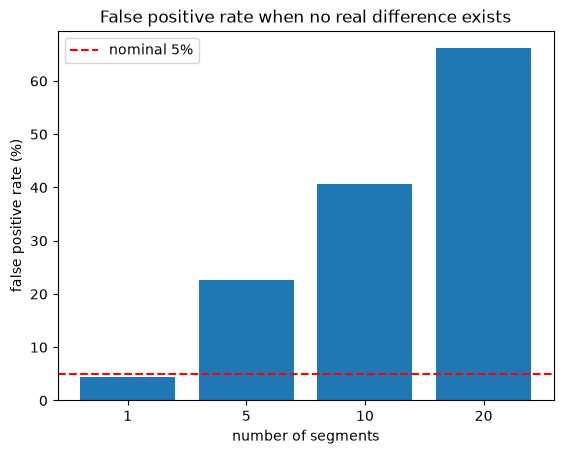

In [9]:
import matplotlib.pyplot as plt

plt.bar([str(k) for k in segments], [r * 100 for r in rates])
plt.axhline(5, color="red", linestyle="--", label="nominal 5%")
plt.xlabel("number of segments")
plt.ylabel("false positive rate (%)")
plt.title("False positive rate when no real difference exists")
plt.legend()
plt.show()

In [7]:
import pandas as pd
pd.DataFrame({
    "세그먼트 수": [f"{k}개" for k in segments],
    "위양성률": [f"{r:.1%}" for r in rates],
})

,세그먼트 수,위양성률
0,1개,4.5%
1,5개,22.6%
2,10개,40.6%
3,20개,66.1%


## 결과

모든 세그먼트에서 두 그룹의 진짜 전환율은 12%로 동일하게 설정했다.
따라서 위 수치는 전부 위양성이다.

세그먼트가 1개일 때 4.5%가 나온 것은 유의수준 0.05의 정의 그대로다.
시뮬레이션이 제대로 작동한다는 확인이기도 하다.

기기 3종 × 신규/기존 2종 × 연령대 4종이면 24개 조합이다.
그중 하나가 유의하게 나오는 것은 발견이 아니라 예정된 일에 가깝다.

In [10]:
from statsmodels.stats.multitest import multipletests

pvals = [0.001, 0.02, 0.03, 0.04, 0.20, 0.45]

r_bh, _, _, _ = multipletests(pvals, alpha=0.05, method="fdr_bh")
r_bf, _, _, _ = multipletests(pvals, alpha=0.05, method="bonferroni")

pd.DataFrame({
    "p값": pvals,
    "보정 전": [p < 0.05 for p in pvals],
    "BH": r_bh,
    "Bonferroni": r_bf,
})

,p값,보정 전,BH,Bonferroni
0,0.001,True,True,True
1,0.020,True,False,False
2,0.030,True,False,False
3,0.040,True,False,False
4,0.200,False,False,False
5,0.450,False,False,False


In [11]:
# 검정 수 증가 및 비교

pvals2 = [0.001, 0.002, 0.004, 0.008, 0.01, 0.015, 0.02, 0.03,
          0.15, 0.22, 0.31, 0.44, 0.55, 0.61, 0.78, 0.90]

r_bh2, _, _, _ = multipletests(pvals2, alpha=0.05, method="fdr_bh")
r_bf2, _, _, _ = multipletests(pvals2, alpha=0.05, method="bonferroni")

print(f"검정 16개 → BH {r_bh2.sum()}개, Bonferroni {r_bf2.sum()}개 통과")

검정 16개 → BH 7개, Bonferroni 2개 통과


## 보정 결과

보정 전에는 6개 중 4개가 유의하다. BH와 Bonferroni 모두 1개만
남긴다. 0.02는 단독으로는 유의하지만, 6개를 함께 본 상황에서는
우연히 나올 만한 값이다.

두 방법이 같은 결과를 낸 것은 검정 수가 적고 p값이 애매한 구간에
몰려 있기 때문이다. 검정 수가 20~50개로 늘면 BH가 더 많이 살린다.
Bonferroni는 기준을 개수로 단순히 나누므로 지나치게 엄격해져
진짜 효과까지 놓치기 쉽다. 실무에서는 BH를 쓴다.

## 보정보다 중요한 것

보정은 "20개를 봤다"고 인정할 때 쓰는 도구다. 그런데 실무에서
흔한 흐름은 이렇다.

1. 전체 결과 확인 → 유의하지 않음
2. 기기별로 쪼갬 → 모바일에서 유의
3. "모바일에서는 효과가 있다"고 보고

2단계에서 몇 개를 봤는지 기록되지 않으므로 보정 자체가 불가능하다.
실험 전에 볼 세그먼트를 지정해두는 편이 확실하다.

## peeking과의 차이

- **다중검정** (서로 다른 세그먼트 20개) → 위양성률 66%
- **엿보기** (같은 실험을 30회 확인) → 위양성률 26%

엿보기는 데이터가 누적되므로 어제 p값과 오늘 p값이 크게 다르지 않다.
다중검정은 매번 독립적인 기회이므로 더 가파르게 오른다.